In [1]:
import numpy as np
import matplotlib.pyplot as plt
from netCDF4 import Dataset
import os

## Initial conditions — test142 to test150

Replicates the **test41** setup (slope width = 5 grid cells, depth 100→500 m, tanh velocity)
across 9 different grid resolutions.

**Fixed across all experiments:**
- Domain: $L_x = 1000$ km, $L_y = 400$ km
- Velocity: $u = U\tanh\!\left(\frac{y - Y_j}{L_\mathrm{jet}}\right)$, $U=0.20$ m/s, $L_\mathrm{jet}=10$ km
- Topography: shelf 100 m, slope width = 5 grid cells centred at $Y_s = 200$ km, basin 500 m
- $f = -10^{-5}$ s$^{-1}$

**Varies between experiments — grid resolution (dx = dy):**

| Experiment | dx = dy | nx    | ny   |
|------------|---------|-------|------|
| test342    | 900 m   | 1111  | 444  |
| test343    | 800 m   | 1250  | 500  |
| test344    | 700 m   | 1428  | 571  |
| test345    | 600 m   | 1666  | 666  |
| test346    | 500 m   | 2000  | 800  |
| test347    | 400 m   | 2500  | 1000 |
| test348    | 300 m   | 3333  | 1333 |
| test349    | 200 m   | 5000  | 2000 |
| test350    | 100 m   | 10000 | 4000 |

> **Note:** 700 m and 600 m do not divide evenly into the domain lengths.
> `nx` and `ny` are truncated with `int()`, so the effective domain is
> very slightly smaller than 1000 × 400 km for those two cases.

### Shared physical constants

In [2]:
# Domain size (fixed)
Lx = 500e3   # m
Ly = 400e3    # m

# Velocity parameters
f    = -1e-5   # s^-1
g    = 9.81    # m s^-2
U    = 0.20    # m s^-1  jet amplitude
Ljet = 10e3   # m       jet half-width
Yj   = Ly / 2  # m       jet centre

# Bathymetry parameters (fixed physical scales)
shallow_depth  = 100.0   # m  shelf depth
deep_depth     = 500.0   # m  basin depth
slope_width_m  = 5000.0  # m  physical slope width (5 km) — FIXED across all resolutions
Ys             = 200e3   # m  slope centre (200 km)

### Experiment loop

In [3]:
base_dir = '/scratch/nm03/ae7501/mom6_input_directories/idealized'

# (experiment_number, resolution_in_metres)
experiments = [(342 + i, res) for i, res in enumerate(range(900, 199, -100))]

for exp_num, res in experiments:

    exp_name  = f'test{exp_num}'
    input_dir = os.path.join(base_dir, exp_name, 'INPUT')
    os.makedirs(input_dir, exist_ok=True)

    # ── Grid for this resolution ──────────────────────────────────────────────
    dx  = res
    dy  = res
    nx  = int(Lx / dx)
    ny  = int(Ly / dy)
    nxp = nx + 1
    nyp = ny + 1

    xh = np.linspace(dx/2, nx*dx - dx/2, nx)
    yh = np.linspace(dy/2, ny*dy - dy/2, ny)
    xq = np.linspace(0, nx*dx, nxp)
    yq = np.linspace(0, ny*dy, nyp)

    Xh, Yh   = np.meshgrid(xh, yh)
    Xq, Yh_u = np.meshgrid(xq, yh)
    Xh_v, Yq = np.meshgrid(xh, yq)

    # ── Slope indices — physical 5 km width, centred at Ys=200 km ─────────────
    slope_width_cells = int(slope_width_m / dy)          # cells at this resolution
    physical_width_actual = slope_width_cells * dy       # actual width after rounding
    half_width  = slope_width_m / 2.0
    slope_start = int(round((Ys - half_width) / dy))     # left edge closest to Ys-2.5km
    slope_end   = slope_start + slope_width_cells

    print(f"\n{'='*60}")
    print(f' {exp_name}  |  dx=dy={res}m  nx={nx}  ny={ny}')
    print(f' slope: {slope_width_cells} cells = {physical_width_actual/1e3:.1f} km'
          f'  [{yh[slope_start]/1e3:.2f}, {yh[slope_end-1]/1e3:.2f}] km')

    # ── Velocity field ────────────────────────────────────────────────────────
    yprime_u = (Yh_u - Yj) / Ljet
    u_clean  = U * np.tanh(yprime_u)
    v        = np.zeros((nyp, nx))

    # Fixed-seed noise (reproducible, same character across resolutions)
    rng          = np.random.default_rng(seed=42)
    random_noise = rng.standard_normal(u_clean.shape)
    decay_factor = 1.0 / np.cosh(yprime_u)**2
    u            = u_clean + 1e-3 * decay_factor * random_noise

    # ── Free surface (geostrophically balanced) ───────────────────────────────
    yprime_h = (Yh - Yj) / Ljet
    eta_t    = -(f * U * Ljet / g) * np.log(np.cosh(yprime_h))
    eta_t   -= eta_t.mean()

    # ── Bathymetry ────────────────────────────────────────────────────────────
    depth_profile_y = np.zeros(ny)
    depth_profile_y[:slope_start]          = shallow_depth
    depth_profile_y[slope_start:slope_end] = np.linspace(shallow_depth, deep_depth, slope_width_cells)
    depth_profile_y[slope_end:]            = deep_depth
    depth_2d = np.tile(depth_profile_y[:, np.newaxis], (1, nx))

    # 3-D arrays for NetCDF
    zl   = 1
    z    = np.array([-250.0])
    h_3d = eta_t[np.newaxis, :, :]
    u_3d = u    [np.newaxis, :, :]
    v_3d = v    [np.newaxis, :, :]

    # ── Write init_vel.nc ─────────────────────────────────────────────────────
    vel_path = os.path.join(input_dir, 'init_vel.nc')
    nc_vel   = Dataset(vel_path, 'w', format='NETCDF4')
    nc_vel.createDimension('zl', zl)
    nc_vel.createDimension('yh', ny)
    nc_vel.createDimension('xh', nx)
    nc_vel.createDimension('yq', nyp)
    nc_vel.createDimension('xq', nxp)

    zl_v = nc_vel.createVariable('zl', 'f4', ('zl',))
    zl_v[:] = z ; zl_v.axis = 'Z' ; zl_v.long_name = 'depth to layer'

    xh_v = nc_vel.createVariable('xh', 'f4', ('xh',))
    xh_v[:] = xh ; xh_v.axis = 'X'
    xh_v.long_name = 'h-point longitude' ; xh_v.units = 'meters'

    yh_v = nc_vel.createVariable('yh', 'f4', ('yh',))
    yh_v[:] = yh ; yh_v.axis = 'Y'
    yh_v.long_name = 'h-point latitude' ; yh_v.units = 'meters'

    xq_v = nc_vel.createVariable('xq', 'f4', ('xq',))
    xq_v[:] = xq ; xq_v.axis = 'X'
    xq_v.long_name = 'q-point longitude' ; xq_v.units = 'meters'

    yq_v = nc_vel.createVariable('yq', 'f4', ('yq',))
    yq_v[:] = yq ; yq_v.axis = 'Y'
    yq_v.long_name = 'q-point latitude' ; yq_v.units = 'meters'

    u_var = nc_vel.createVariable('u', 'f4', ('zl', 'yh', 'xq'))
    u_var[:] = u_3d
    u_var.units = 'm s-1'
    u_var.long_name = 'Eastward velocity'
    u_var.standard_name = 'eastward_sea_water_velocity'

    v_var = nc_vel.createVariable('v', 'f4', ('zl', 'yq', 'xh'))
    v_var[:] = v_3d
    v_var.units = 'm s-1'
    v_var.long_name = 'Northward velocity'
    v_var.standard_name = 'northward_sea_water_velocity'

    nc_vel.regrid_method = 'bilinear'
    nc_vel.close()
    print(f' Written: {vel_path}')

    # ── Write init_eta.nc ─────────────────────────────────────────────────────
    eta_path = os.path.join(input_dir, 'init_eta.nc')
    nc_h     = Dataset(eta_path, 'w', format='NETCDF4')
    nc_h.createDimension('yh', ny)
    nc_h.createDimension('xh', nx)

    xh_v2 = nc_h.createVariable('xh', 'f4', ('xh',))
    xh_v2[:] = xh ; xh_v2.axis = 'X'
    xh_v2.long_name = 'h-point longitude' ; xh_v2.units = 'meters'

    yh_v2 = nc_h.createVariable('yh', 'f4', ('yh',))
    yh_v2[:] = yh ; yh_v2.axis = 'Y'
    yh_v2.long_name = 'h-point latitude' ; yh_v2.units = 'meters'

    h_var = nc_h.createVariable('eta_t', 'f4', ('yh', 'xh'))
    h_var[:] = h_3d
    h_var.units = 'm'
    h_var.long_name = 'Free surface height anomaly'
    h_var.standard_name = 'sea_floor_depth_below_sea_surface'

    nc_h.close()
    print(f' Written: {eta_path}')

    # ── Write ocean_topog.nc ──────────────────────────────────────────────────
    topo_path = os.path.join(input_dir, 'ocean_topog.nc')
    nc_d      = Dataset(topo_path, 'w', format='NETCDF4')
    nc_d.createDimension('yh', ny)
    nc_d.createDimension('xh', nx)

    xh_d = nc_d.createVariable('xh', 'f4', ('xh',))
    xh_d[:] = xh
    xh_d.long_name = 't-cell center x-location' ; xh_d.units = 'meters'

    yh_d = nc_d.createVariable('yh', 'f4', ('yh',))
    yh_d[:] = yh
    yh_d.long_name = 't-cell center y-location' ; yh_d.units = 'meters'

    depth_var = nc_d.createVariable('depth', 'f4', ('yh', 'xh'))
    depth_var[:] = depth_2d
    depth_var.units = 'm'
    depth_var.long_name = 'ocean bottom depth'
    depth_var.standard_name = 'sea_floor_depth_below_geoid'

    nc_d.close()
    print(f' Written: {topo_path}')

print(f"\n{'='*60}")
print('All 9 experiments written successfully (test142-test150).')
print(f"{'='*60}")


 test342  |  dx=dy=900m  nx=555  ny=444
 slope: 5 cells = 4.5 km  [197.55, 201.15] km
 Written: /scratch/nm03/ae7501/mom6_input_directories/idealized/test342/INPUT/init_vel.nc
 Written: /scratch/nm03/ae7501/mom6_input_directories/idealized/test342/INPUT/init_eta.nc
 Written: /scratch/nm03/ae7501/mom6_input_directories/idealized/test342/INPUT/ocean_topog.nc

 test343  |  dx=dy=800m  nx=625  ny=500
 slope: 6 cells = 4.8 km  [198.00, 202.00] km
 Written: /scratch/nm03/ae7501/mom6_input_directories/idealized/test343/INPUT/init_vel.nc
 Written: /scratch/nm03/ae7501/mom6_input_directories/idealized/test343/INPUT/init_eta.nc
 Written: /scratch/nm03/ae7501/mom6_input_directories/idealized/test343/INPUT/ocean_topog.nc

 test344  |  dx=dy=700m  nx=714  ny=571
 slope: 7 cells = 4.9 km  [197.75, 201.95] km
 Written: /scratch/nm03/ae7501/mom6_input_directories/idealized/test344/INPUT/init_vel.nc
 Written: /scratch/nm03/ae7501/mom6_input_directories/idealized/test344/INPUT/init_eta.nc
 Written: /sc

### Sanity-check plot — bathymetry profiles for all resolutions

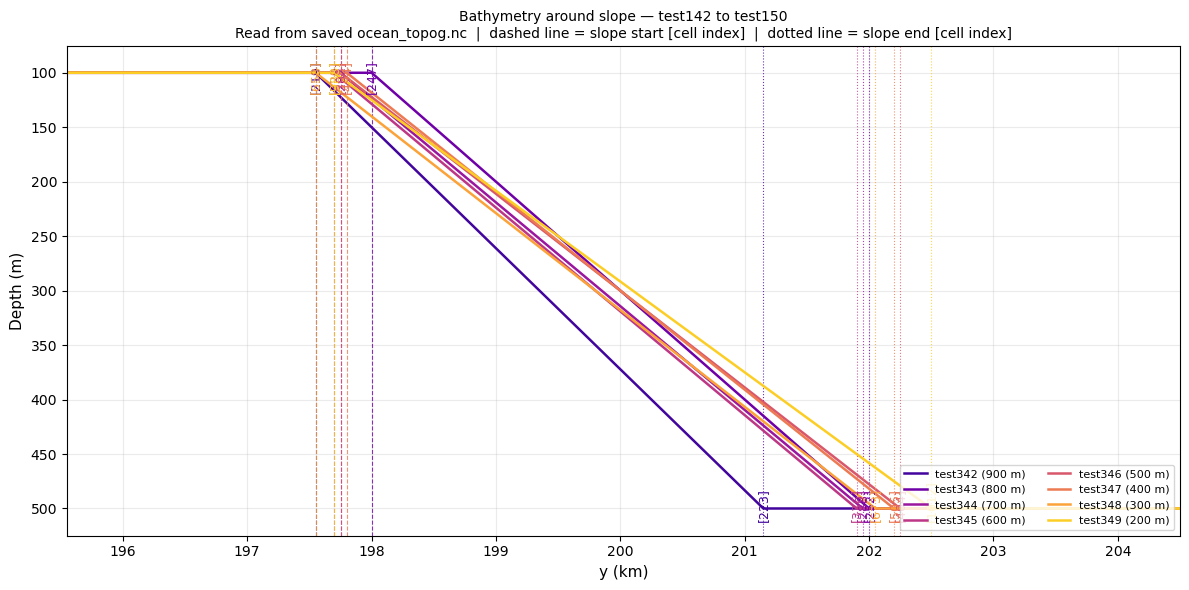

Plot saved: bathy_slope_check_test142_150.png


In [4]:
from netCDF4 import Dataset as NC
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

base_dir  = '/scratch/nm03/ae7501/mom6_input_directories/idealized'
experiments = [(342 + i, res) for i, res in enumerate(range(900, 199, -100))]

shallow_depth = 100.0
deep_depth    = 500.0

fig, ax = plt.subplots(figsize=(12, 6))
colors = plt.cm.plasma(np.linspace(0.1, 0.9, len(experiments)))

all_ss_km = []
all_se_km = []
all_ss_idx = []   
all_se_idx = []   

for i, (exp_num, res) in enumerate(experiments):
    topo_path = f'{base_dir}/test{exp_num}/INPUT/ocean_topog.nc'

    # Read saved bathymetry
    nc      = NC(topo_path, 'r')
    yh      = nc.variables['yh'][:]
    depth   = nc.variables['depth'][:]
    nc.close()

    # 1-D profile at x midpoint
    profile = depth[:, depth.shape[1] // 2]

    # Detect slope start and end using depth gradient
    # Slope cells are where depth is changing — gradient exceeds half the mean slope gradient
    grad      = np.diff(profile)
    threshold = (deep_depth - shallow_depth) / (len(profile) * 0.1)
    on_slope  = np.where(np.abs(grad) > threshold)[0]
    ss = int(on_slope[0])          # first changing cell = slope start
    se = int(on_slope[-1]) + 1     # cell after last changing cell = slope end

    all_ss_idx.append(ss)
    all_se_idx.append(se)

    ss_km = float(yh[ss]) / 1e3
    se_km = float(yh[se]) / 1e3
    all_ss_km.append(ss_km)
    all_se_km.append(se_km)

    # Plot full profile
    ax.plot(yh / 1e3, profile, color=colors[i], lw=1.8,
            label=f'test{exp_num} ({res} m)')

    # Mark slope start — dashed line, cell index below shelf level
    ax.axvline(ss_km, color=colors[i], lw=0.8, ls='--', alpha=0.8)
    ax.text(ss_km, 88, f'[{ss}]', color=colors[i],
            fontsize=9, ha='center', va='top', rotation=90)

    # Mark slope end — dotted line, cell index above basin level
    ax.axvline(se_km, color=colors[i], lw=0.8, ls=':', alpha=0.8)
    ax.text(se_km, 512, f'[{se}]', color=colors[i],
            fontsize=9, ha='center', va='bottom', rotation=90)

# Zoom: 2 km padding around widest slope extent across all experiments
pad = 2.0
ax.set_xlim(min(all_ss_km) - pad, max(all_se_km) + pad)
ax.set_ylim(75, 525)
ax.invert_yaxis()

ax.set_xlabel('y (km)', fontsize=11)
ax.set_ylabel('Depth (m)', fontsize=11)
ax.set_title(
    'Bathymetry around slope — test142 to test150\n'
    'Read from saved ocean_topog.nc  |  '
    'dashed line = slope start [cell index]  |  '
    'dotted line = slope end [cell index]',
    fontsize=10)
ax.yaxis.set_major_locator(ticker.MultipleLocator(50))
ax.grid(True, alpha=0.25)
ax.legend(loc='lower right', fontsize=8, ncol=2)

plt.tight_layout()
plt.savefig('bathy_slope_check_test142_150.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot saved: bathy_slope_check_test142_150.png')


In [5]:
print(f"{'Experiment':<12} {'dx (m)':>7} {'ss (cell)':>10} {'se (cell)':>10} "
      f"{'y_start (km)':>13} {'y_end (km)':>11} {'width (km)':>11}")
print("-" * 78)

for (exp_num, res), ss_idx, se_idx, ss_km, se_km in zip(
        experiments, all_ss_idx, all_se_idx, all_ss_km, all_se_km):
    width_km = se_km - ss_km
    print(f"test{exp_num:<8} {res:>7} {ss_idx:>10} {se_idx:>10} "
          f"{ss_km:>13.3f} {se_km:>11.3f} {width_km:>11.3f}")

Experiment    dx (m)  ss (cell)  se (cell)  y_start (km)  y_end (km)  width (km)
------------------------------------------------------------------------------
test342          900        219        223       197.550     201.150       3.600
test343          800        247        252       198.000     202.000       4.000
test344          700        282        288       197.750     201.950       4.200
test345          600        329        336       197.700     201.900       4.200
test346          500        395        404       197.750     202.250       4.500
test347          400        494        505       197.800     202.200       4.400
test348          300        658        673       197.550     202.050       4.500
test349          200        988       1012       197.700     202.500       4.800


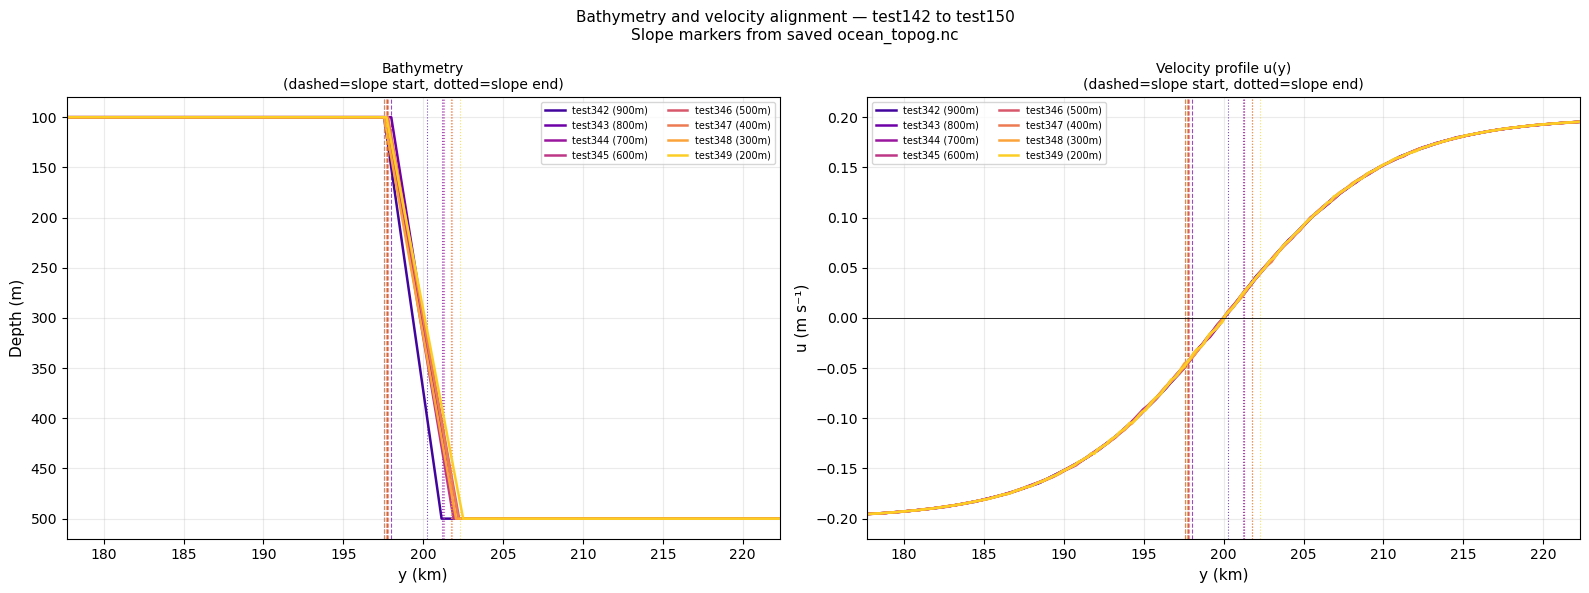

In [6]:
from netCDF4 import Dataset as NC
import numpy as np
import matplotlib.pyplot as plt

base_dir    = '/scratch/nm03/ae7501/mom6_input_directories/idealized'
experiments = [(342 + i, res) for i, res in enumerate(range(900, 199, -100))]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
colors = plt.cm.plasma(np.linspace(0.1, 0.9, len(experiments)))

for i, (exp_num, res) in enumerate(experiments):

    # ── Read bathymetry ───────────────────────────────────────────
    nc      = NC(f'{base_dir}/test{exp_num}/INPUT/ocean_topog.nc', 'r')
    yh      = nc.variables['yh'][:]
    depth2d = nc.variables['depth'][:]
    nc.close()
    depth   = depth2d[:, depth2d.shape[1] // 2]

    # ── Read velocity ─────────────────────────────────────────────
    nc      = NC(f'{base_dir}/test{exp_num}/INPUT/init_vel.nc', 'r')
    yh_u    = nc.variables['yh'][:]     # velocity yh (same as bathy yh)
    xq      = nc.variables['xq'][:]
    u_3d    = nc.variables['u'][:]      # shape (1, ny, nxp)
    nc.close()
    u_1d    = u_3d[0, :, u_3d.shape[2] // 2]   # mid-x column, 1-D

    # ── Detect slope start/end from bathymetry ────────────────────
    grad      = np.diff(depth)
    threshold = (500.0 - 100.0) / (len(depth) * 0.1)
    on_slope  = np.where(np.abs(grad) > threshold)[0]
    ss_km     = yh[on_slope[0]]  / 1e3
    se_km     = yh[on_slope[-1]] / 1e3

    # ── Left: bathymetry zoomed around slope ──────────────────────
    ax = axes[0]
    ax.plot(yh / 1e3, depth, color=colors[i], lw=1.8,
            label=f'test{exp_num} ({res}m)')
    ax.axvline(ss_km, color=colors[i], lw=0.8, ls='--', alpha=0.7)
    ax.axvline(se_km, color=colors[i], lw=0.8, ls=':', alpha=0.7)

    # ── Right: velocity profile zoomed around slope ───────────────
    ax = axes[1]
    ax.plot(yh_u / 1e3, u_1d, color=colors[i], lw=1.8,
            label=f'test{exp_num} ({res}m)')
    ax.axvline(ss_km, color=colors[i], lw=0.8, ls='--', alpha=0.7)
    ax.axvline(se_km, color=colors[i], lw=0.8, ls=':', alpha=0.7)

# ── Formatting ────────────────────────────────────────────────────
pad = 20   # km either side of slope

axes[0].set_xlim(ss_km - pad, se_km + pad)
axes[0].set_ylim(80, 520)
axes[0].invert_yaxis()
axes[0].set_xlabel('y (km)', fontsize=11)
axes[0].set_ylabel('Depth (m)', fontsize=11)
axes[0].set_title('Bathymetry\n(dashed=slope start, dotted=slope end)', fontsize=10)
axes[0].grid(True, alpha=0.25)
axes[0].legend(fontsize=7, ncol=2)

axes[1].set_xlim(ss_km - pad, se_km + pad)
axes[1].axhline(0, color='k', lw=0.6)
axes[1].set_xlabel('y (km)', fontsize=11)
axes[1].set_ylabel('u (m s⁻¹)', fontsize=11)
axes[1].set_title('Velocity profile u(y)\n(dashed=slope start, dotted=slope end)', fontsize=10)
axes[1].grid(True, alpha=0.25)
axes[1].legend(fontsize=7, ncol=2)

plt.suptitle('Bathymetry and velocity alignment — test142 to test150\n'
             'Slope markers from saved ocean_topog.nc', fontsize=11)
plt.tight_layout()
plt.show()